In [1]:
import pandas as pd

df = pd.read_csv("../data/mwd_data.csv")

# Features (inputs)
X = df.drop(columns=["ROP (m/hr)"])

# Target (output)
y = df["ROP (m/hr)"]

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [4]:
y_pred = model.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 3.3366421195136833
R2 Score: 0.8717941274515628


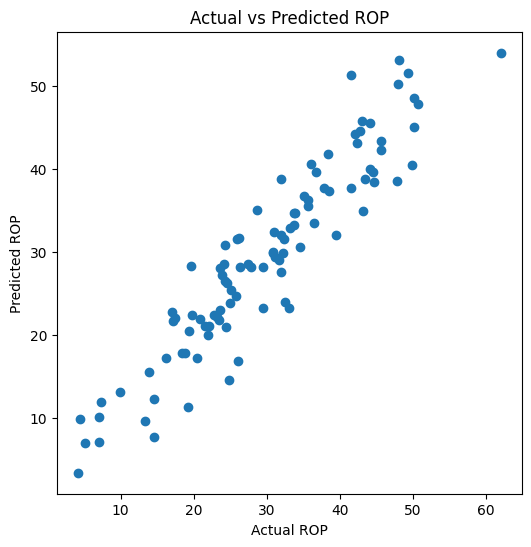

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("Actual vs Predicted ROP")
plt.show()

In [7]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_
})

print(coefficients.sort_values(by="Importance", ascending=False))

                    Feature  Importance
1                WOB (klbs)    0.520139
4          Mud Weight (ppg)    0.474865
2                       RPM    0.291275
3           Flow Rate (gpm)   -0.001059
6  Standpipe Pressure (psi)   -0.002158
0                 Depth (m)   -0.009357
5             Torque (kN.m)   -0.034310
7         Inclination (deg)   -0.092919


### RPM and WOB have strong influence on ROP

### We’ll add:

- Random Forest 
- Gradient Boosting 
- XGBoost 

In [8]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE        R2
0  Linear Regression  3.336642  0.871794
1      Random Forest  4.247892  0.791385
2  Gradient Boosting  4.023745  0.813356


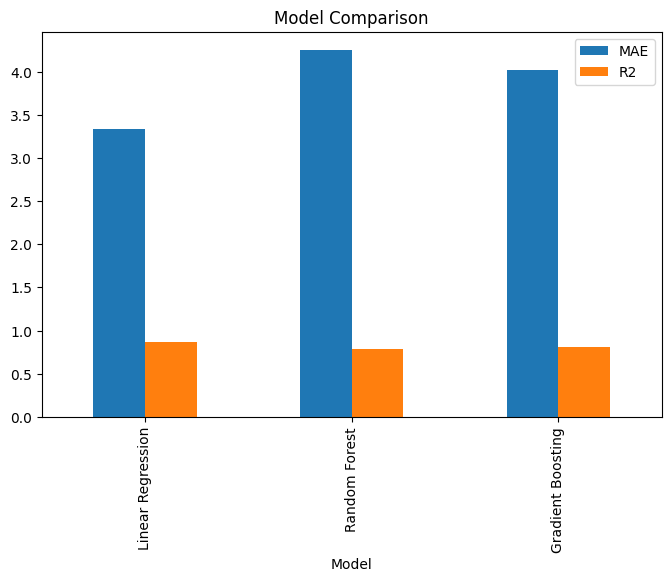

In [10]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[["MAE", "R2"]].plot(kind="bar", figsize=(8,5))
plt.title("Model Comparison")
plt.show()

### XGBOOST

In [11]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost MAE: 4.757920309103939
XGBoost R2: 0.7430251019247358


### We tune the best model

In [12]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [13]:
y_pred_best = best_model.predict(X_test)

print("Final MAE:", mean_absolute_error(y_test, y_pred_best))
print("Final R2:", r2_score(y_test, y_pred_best))

Final MAE: 4.284087200826027
Final R2: 0.790086526545414


##### WOB had the strongest influence on ROP, which aligns with drilling physics
##### RPM contributes positively to drilling efficiency

### BUILD USING RANDOM FOREST

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
y_pred_rf = rf_model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 4.2478917261880955
Random Forest R2: 0.7913852010411968


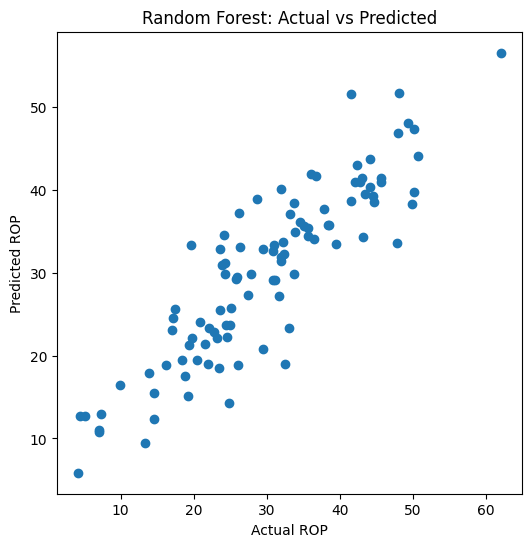

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [18]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

                    Feature  Importance
2                       RPM    0.523903
0                 Depth (m)    0.214245
1                WOB (klbs)    0.144032
5             Torque (kN.m)    0.029306
3           Flow Rate (gpm)    0.027313
4          Mud Weight (ppg)    0.023701
7         Inclination (deg)    0.020584
6  Standpipe Pressure (psi)    0.016916


#### I moved from a linear baseline to an ensemble model to better capture non-linear drilling dynamics

### TUNE RANDOM FOREST WITH GRIDSEARCHCV

In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
### DEFINE PARAMETER GRID
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}


In [21]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [22]:
### TRAIN GRIDSEARCH
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END ..max_depth=5, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END ..max_depth=5, min_samples_split=5, n_estimators=50; total time=   0.1s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END .max_depth=5, min_samples_split=2, n_estimators=200; total time=   0.5s
[CV] END .max_depth=5, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END .max_depth=5, min_s

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='r2', verbose=2)

In [23]:
### GET BEST PARAMETERS
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 50}


In [24]:
### GET BEST MODEL
best_rf = grid_search.best_estimator_

In [25]:
### PREDICTion
y_pred_best = best_rf.predict(X_test)

In [26]:
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Tuned RF MAE:", mae_best)
print("Tuned RF R2:", r2_best)

Tuned RF MAE: 4.255102119837199
Tuned RF R2: 0.7951107874992351


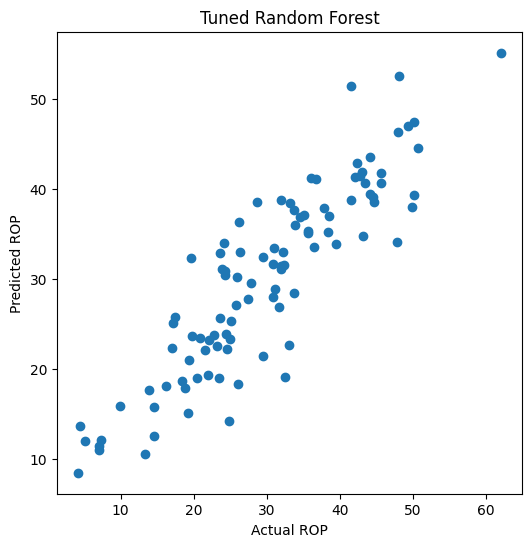

In [27]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("Tuned Random Forest")
plt.show()

| Model               | MAE        | R²         |
| ------------------- | ---------- | ---------- |
| Linear Regression   | **3.33** ✅ | **0.87** ✅ |
| Random Forest       | 4.24       | 0.79       |
| Tuned Random Forest | 4.25       | 0.795      |

#### That tell us that the best algorithm in termes of nombers  is **Linear Regression** 

“The simulated drilling dataset exhibited mostly structured and near-linear relationships. Ensemble methods provided limited improvement, while Linear Regression achieved the strongest generalization performance.”

## now let us try XGBOOST

#### WHAT IS XGBOOST?

##### XGBoost = Extreme Gradient Boosting

##### It is one of the strongest ML algorithms for:

- tabular data
- engineering datasets
- structured business data

##### Used heavily in:

- finance
- energy
- forecasting
- industrial analytics

In [28]:
####IMPORT XGBOOST
from xgboost import XGBRegressor

In [29]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

In [30]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [31]:
y_pred_xgb = xgb_model.predict(X_test)

In [32]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost MAE:", mae_xgb)
print("XGBoost R2:", r2_xgb)

XGBoost MAE: 4.613802141719148
XGBoost R2: 0.7628149359797147


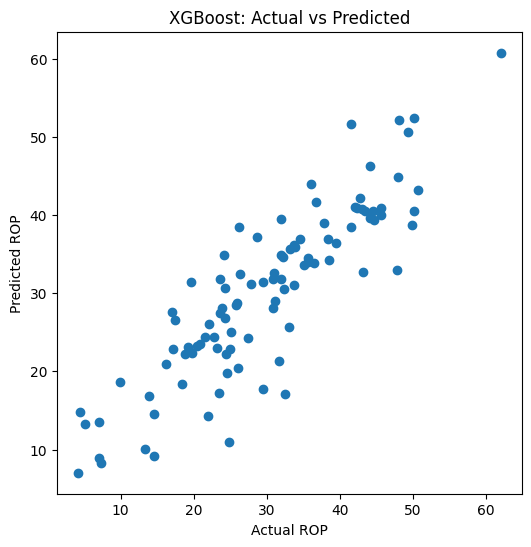

In [33]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("XGBoost: Actual vs Predicted")
plt.show()

In [34]:
importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

print(importance_xgb.sort_values(by='Importance', ascending=False))

                    Feature  Importance
2                       RPM    0.519695
0                 Depth (m)    0.183843
1                WOB (klbs)    0.142314
5             Torque (kN.m)    0.037298
4          Mud Weight (ppg)    0.032434
3           Flow Rate (gpm)    0.030514
6  Standpipe Pressure (psi)    0.028813
7         Inclination (deg)    0.025090


#### FINAL MODEL COMPARISON

| Model               | MAE      | R²       |
| ------------------- | -------- | -------- |
| ✅ Linear Regression | **3.33** | **0.87** |
| Random Forest       | 4.24     | 0.79     |
| Tuned RF            | 4.25     | 0.795    |
| XGBoost             | 4.61     | 0.76     |


#### This is your MOST important finding:

#### 🔥 SIMPLE MODEL WON